In [2]:
# ================================================================
# Notebook 04. Phase 2 SSVI surface calibration
# ================================================================
# Single surface-level fit across all maturities. 3 parameters: rho, eta,
# gamma (power-law phi). ATM term structure theta_t derived from the data.
# Calendar arbitrage-free by construction (theta monotone in T). Butterfly
# arbitrage enforced via SLSQP inequality constraints (Gatheral-Jacquier
# Corollary 4.1). Vega-weighted loss in IV space.

# ----------------------------------------------------------------
# 0. Setup
# ----------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

import sys
sys.path.insert(0, '/content/drive/MyDrive/Vol_fitter')




import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from scipy.stats import norm
import plotly.graph_objects as go
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
pio.renderers.default = 'colab'

from volsurf.paths import PROJECT_ROOT, PROCESSED_DIR, FITTED_DIR, AUX_DIR
from volsurf.pricing import bs_vega

VOLSURF_PKG = PROJECT_ROOT / 'volsurf'

Mounted at /content/drive


In [3]:
# ----------------------------------------------------------------
# 1. Load the de-Americanised snapshot
# ----------------------------------------------------------------
SNAP_DATE = '2010-06-15'
snap = pd.read_parquet(PROCESSED_DIR / f'chain_{SNAP_DATE}.parquet')
snap = snap.rename(columns={'T': 'tau'})

snap['w'] = snap.iv_mid ** 2 * snap.tau
snap = snap[snap.iv_mid.between(0.05, 2.0) & snap.k.between(-0.5, 0.3)].reset_index(drop=True)

print(f'Loaded {len(snap):,} quotes across {snap.expiry.nunique()} expiries')
print(f'  S = {snap.S.iloc[0]:.2f}, snapshot date = {SNAP_DATE}')
print(f'  tau range: {snap.tau.min():.4f} to {snap.tau.max():.4f}')

Loaded 674 quotes across 15 expiries
  S = 111.98, snapshot date = 2010-06-15
  tau range: 0.0082 to 2.5207


In [4]:
# ----------------------------------------------------------------
# 2. SSVI parameterisation and analytic derivatives
# ----------------------------------------------------------------
# Gatheral-Jacquier 2014:
#   w(k, theta) = (theta/2) * [1 + rho*phi*k + sqrt((phi*k + rho)^2 + (1 - rho^2))]
# Power-law curvature function:
#   phi(theta) = eta * theta^(-gamma)
# Three free parameters: rho, eta, gamma. theta_T comes from the data.

@dataclass(frozen=True)
class SSVIParams:
    rho: float
    eta: float
    gamma: float

def phi_power_law(theta, eta, gamma):
    return eta * np.power(theta, -gamma)

def ssvi_w(k, theta, p):
    """SSVI total variance."""
    phi = phi_power_law(theta, p.eta, p.gamma)
    z = phi * k
    return 0.5 * theta * (1.0 + p.rho * z + np.sqrt((z + p.rho) ** 2 + (1.0 - p.rho ** 2)))

def ssvi_dw_dk(k, theta, p):
    """First derivative of total variance with respect to log-moneyness."""
    phi = phi_power_law(theta, p.eta, p.gamma)
    z = phi * k
    inner_root = np.sqrt((z + p.rho) ** 2 + (1.0 - p.rho ** 2))
    return 0.5 * theta * phi * (p.rho + (z + p.rho) / inner_root)

def ssvi_d2w_dk2(k, theta, p):
    """Second derivative of total variance with respect to log-moneyness."""
    phi = phi_power_law(theta, p.eta, p.gamma)
    z = phi * k
    denom = np.power((z + p.rho) ** 2 + (1.0 - p.rho ** 2), 1.5)
    return 0.5 * theta * (phi ** 2) * (1.0 - p.rho ** 2) / denom

def ssvi_iv(k, T, theta, p):
    return np.sqrt(ssvi_w(k, theta, p) / T)

# Smoke test: at k=0, w should equal theta
test_p = SSVIParams(rho=-0.6, eta=1.0, gamma=0.3)
for theta_test in [0.005, 0.05, 0.1]:
    w0 = ssvi_w(0.0, theta_test, test_p)
    print(f'  ssvi_w(k=0, theta={theta_test}) = {w0:.6f}  (expected: {theta_test})')

  ssvi_w(k=0, theta=0.005) = 0.005000  (expected: 0.005)
  ssvi_w(k=0, theta=0.05) = 0.050000  (expected: 0.05)
  ssvi_w(k=0, theta=0.1) = 0.100000  (expected: 0.1)


In [5]:
# ----------------------------------------------------------------
# 3. ATM total variance term structure (theta_t)
# ----------------------------------------------------------------
# For each maturity, fit a small quadratic to quotes within +/- 0.1 of ATM
# in log-moneyness, then evaluate at k=0. This gives the empirical theta_T.
# Then enforce monotonicity in T via cumulative maximum, which prevents
# calendar arbitrage at ATM by construction.

def build_atm_theta_curve(snap, k_window=0.1):
    rows = []
    for expiry, slice_df in snap.groupby('expiry'):
        sdf = slice_df.sort_values('k').reset_index(drop=True)
        near = sdf[sdf.k.between(-k_window, k_window)]
        if len(near) >= 3:
            coeffs = np.polyfit(near.k.values, near.w.values, 2)
            theta = float(np.polyval(coeffs, 0.0))
        elif len(sdf) >= 1:
            i_nearest = int(sdf.k.abs().idxmin())
            theta = float(sdf.loc[i_nearest, 'w'])
        else:
            continue
        T = float(sdf.tau.iloc[0])
        rows.append({'expiry': expiry, 'T': T, 'theta_raw': theta, 'n_near': len(near)})

    atm = pd.DataFrame(rows).sort_values('T').reset_index(drop=True)
    # Enforce monotonicity: theta must be non-decreasing in T
    atm['theta'] = np.maximum.accumulate(atm.theta_raw.values)
    atm['theta_adjusted'] = atm.theta != atm.theta_raw
    return atm

atm_curve = build_atm_theta_curve(snap)
print('ATM theta_T term structure:')
print(atm_curve[['T', 'theta_raw', 'theta', 'theta_adjusted', 'n_near']].to_string(
    index=False, float_format=lambda x: f'{x:.6f}'))
print(f'\n  {atm_curve.theta_adjusted.sum()} maturities adjusted upward to enforce monotonicity')

ATM theta_T term structure:
       T  theta_raw    theta  theta_adjusted  n_near
0.008219   0.000535 0.000535           False      14
0.041096   0.001969 0.001969           False      19
0.084932   0.004402 0.004402           False      20
0.180822   0.009872 0.009872           False      23
0.257534   0.014753 0.014753           False      22
0.293151   0.016823 0.016823           False      22
0.506959   0.031130 0.031130           False      22
0.545315   0.033288 0.033288           False      22
0.756164   0.047416 0.047416           False      22
0.791781   0.049752 0.049752           False      22
1.005479   0.064024 0.064024           False       5
1.504219   0.099396 0.099396           False       5
1.542575   0.101896 0.101896           False       8
1.600110   0.105772 0.105772           False       5
2.520658   0.170249 0.170249           False       4

  0 maturities adjusted upward to enforce monotonicity


In [6]:
# ----------------------------------------------------------------
# 4. SSVI calibration via SLSQP
# ----------------------------------------------------------------
# Loss: vega-weighted squared IV residuals.
# Bounds: rho in (-0.999, -0.01) equity prior; eta > 0; 0 < gamma < 0.95.
# Constraints (Gatheral-Jacquier Corollary 4.1, sufficient butterfly):
#   theta * phi * (1 + |rho|) < 4
#   theta * phi^2 * (1 + |rho|) <= 4
# Both checked at theta_min and theta_max for safety.

def fit_ssvi_surface(snap, atm_curve, weights='vega',
                     rho_init=-0.6, eta_init=1.0, gamma_init=0.3,
                     verbose=False):
    # Attach theta to each quote by merging on expiry
    snap_ = snap.merge(
        atm_curve[['expiry', 'theta']],
        on='expiry', how='left'
    )
    snap_ = snap_[snap_.theta.notna()].reset_index(drop=True)

    k_arr = snap_.k.values
    theta_arr = snap_.theta.values
    T_arr = snap_.tau.values
    iv_market = snap_.iv_mid.values

    # Per-quote weights
    if weights == 'vega':
        F = snap_.F.values
        v = bs_vega(snap_.S.values, snap_.strike.values, T_arr,
                    snap_.r.values, snap_.q.values, iv_market)
        w_quote = np.where(np.isfinite(v) & (v > 1e-6), v, 0.0)
    elif weights == 'uniform':
        w_quote = np.ones_like(k_arr)
    else:
        raise ValueError(f'unknown weights option: {weights}')

    theta_min = atm_curve.theta.min()
    theta_max = atm_curve.theta.max()

    def loss(params):
        rho, eta, gamma = params
        p = SSVIParams(rho=float(rho), eta=float(eta), gamma=float(gamma))
        w_model = ssvi_w(k_arr, theta_arr, p)
        w_model = np.clip(w_model, 1e-10, None)
        iv_model = np.sqrt(w_model / T_arr)
        sq_resid = (iv_model - iv_market) ** 2
        return float(np.sum(w_quote ** 2 * sq_resid))

    def butterfly_1(params, theta_val):
        rho, eta, gamma = params
        phi = eta * np.power(theta_val, -gamma)
        return 4.0 - theta_val * phi * (1.0 + abs(rho)) - 0.01  # 0.01 safety buffer

    def butterfly_2(params, theta_val):
        rho, eta, gamma = params
        phi = eta * np.power(theta_val, -gamma)
        return 4.0 - theta_val * (phi ** 2) * (1.0 + abs(rho))

    constraints = []
    for tv in (theta_min, theta_max):
        constraints.append({'type': 'ineq', 'fun': butterfly_1, 'args': (tv,)})
        constraints.append({'type': 'ineq', 'fun': butterfly_2, 'args': (tv,)})

    bounds = [(-0.999, -0.01), (0.01, 20.0), (0.01, 0.95)]

    res = minimize(loss, [rho_init, eta_init, gamma_init],
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 300, 'disp': verbose})

    params = SSVIParams(rho=float(res.x[0]), eta=float(res.x[1]), gamma=float(res.x[2]))
    return params, res

In [7]:
# ----------------------------------------------------------------
# 5. Fit on test snapshot
# ----------------------------------------------------------------
import time
t0 = time.time()
ssvi_params, res = fit_ssvi_surface(snap, atm_curve, weights='vega', verbose=False)
elapsed = time.time() - t0

print(f'SSVI fit in {elapsed:.2f}s')
print(f'  rho   = {ssvi_params.rho:+.4f}')
print(f'  eta   = {ssvi_params.eta:+.4f}')
print(f'  gamma = {ssvi_params.gamma:+.4f}')
print(f'  converged: {res.success}')
print(f'  message: {res.message}')
print(f'  final loss: {res.fun:.4e}')
print(f'  iterations: {res.nit}')

# Sanity: butterfly conditions at theta extremes
for tv in (atm_curve.theta.min(), atm_curve.theta.max()):
    phi = phi_power_law(tv, ssvi_params.eta, ssvi_params.gamma)
    c1 = 4.0 - tv * phi * (1 + abs(ssvi_params.rho))
    c2 = 4.0 - tv * phi**2 * (1 + abs(ssvi_params.rho))
    print(f'  theta={tv:.6f}: butterfly1 slack={c1:+.4f}, butterfly2 slack={c2:+.4f}')

SSVI fit in 0.08s
  rho   = -0.7635
  eta   = +0.9379
  gamma = +0.4773
  converged: True
  message: Optimization terminated successfully
  final loss: 8.4437e-01
  iterations: 16
  theta=0.000535: butterfly1 slack=+3.9678, butterfly2 slack=+2.8983
  theta=0.170249: butterfly1 slack=+3.3444, butterfly2 slack=+2.5686


In [8]:
# ----------------------------------------------------------------
# 6. Per-slice fit diagnostics
# ----------------------------------------------------------------
results = []
for expiry, slice_df in snap.groupby('expiry'):
    sdf = slice_df.sort_values('k').reset_index(drop=True)
    T = float(sdf.tau.iloc[0])
    theta_row = atm_curve[atm_curve.expiry == expiry]
    if theta_row.empty:
        continue
    theta_t = float(theta_row.theta.iloc[0])

    iv_model = np.sqrt(ssvi_w(sdf.k.values, theta_t, ssvi_params) / T)
    rmse = float(np.sqrt(np.mean((iv_model - sdf.iv_mid.values) ** 2)))
    results.append({
        'expiry': expiry, 'T': T, 'theta': theta_t,
        'rmse_vp': rmse * 100, 'n_quotes': len(sdf),
    })

ssvi_summary = pd.DataFrame(results).sort_values('T').reset_index(drop=True)
print('SSVI per-slice fit:')
print(ssvi_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

SSVI per-slice fit:
    expiry      T  theta  rmse_vp  n_quotes
2010-06-18 0.0082 0.0005   9.7761        22
2010-06-30 0.0411 0.0020   1.8874        31
2010-07-16 0.0849 0.0044   1.4882        48
2010-08-20 0.1808 0.0099   1.1972        62
2010-09-17 0.2575 0.0148   0.6512        67
2010-09-30 0.2932 0.0168   0.5185        66
2010-12-17 0.5070 0.0311   0.2478        77
2010-12-31 0.5453 0.0333   0.2906        79
2011-03-18 0.7562 0.0474   0.2988        82
2011-03-31 0.7918 0.0498   0.3394        59
2011-06-17 1.0055 0.0640   0.1993        16
2011-12-16 1.5042 0.0994   0.0963        16
2011-12-30 1.5426 0.1019   0.0684        17
2012-01-20 1.6001 0.1058   0.0952        16
2012-12-21 2.5207 0.1702   0.1334        16


In [9]:
# ----------------------------------------------------------------
# 7. SVI baseline vs SSVI comparison
# ----------------------------------------------------------------
svi_fit = pd.read_parquet(FITTED_DIR / f'surface_{SNAP_DATE}.parquet')

compare = ssvi_summary.merge(
    svi_fit[['expiry', 'rmse_iv']].rename(columns={'rmse_iv': 'rmse_svi'}),
    on='expiry', how='left'
)
compare['rmse_svi_vp'] = compare.rmse_svi * 100
compare = compare[['T', 'n_quotes', 'rmse_vp', 'rmse_svi_vp']].rename(
    columns={'rmse_vp': 'rmse_ssvi_vp'})
compare['diff_vp'] = compare.rmse_ssvi_vp - compare.rmse_svi_vp

print('SVI (per-slice) vs SSVI (surface) RMSE in vol points:')
print(compare.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\nMean SVI RMSE:  {compare.rmse_svi_vp.mean():.3f} vp')
print(f'Mean SSVI RMSE: {compare.rmse_ssvi_vp.mean():.3f} vp')

SVI (per-slice) vs SSVI (surface) RMSE in vol points:
     T  n_quotes  rmse_ssvi_vp  rmse_svi_vp  diff_vp
0.0082        22        9.7761       1.8889   7.8872
0.0411        31        1.8874       0.5371   1.3502
0.0849        48        1.4882       0.3196   1.1686
0.1808        62        1.1972       0.1738   1.0235
0.2575        67        0.6512       0.1796   0.4716
0.2932        66        0.5185       0.1572   0.3613
0.5070        77        0.2478       0.0851   0.1627
0.5453        79        0.2906       0.0589   0.2318
0.7562        82        0.2988       0.0537   0.2451
0.7918        59        0.3394       0.0440   0.2955
1.0055        16        0.1993       0.0550   0.1444
1.5042        16        0.0963       0.0556   0.0408
1.5426        17        0.0684       0.0249   0.0435
1.6001        16        0.0952       0.0494   0.0458
2.5207        16        0.1334       0.0652   0.0682

Mean SVI RMSE:  0.250 vp
Mean SSVI RMSE: 1.153 vp


In [10]:
# ----------------------------------------------------------------
# 7b. Vega-weighted RMSE comparison
# ----------------------------------------------------------------
# SSVI was calibrated with vega weights; the unweighted RMSE in cell 7
# does not reflect what SSVI was actually optimising. Add a weighted RMSE
# computed against the same weights SSVI saw during calibration.

snap_w = snap.merge(atm_curve[['expiry', 'theta']], on='expiry', how='left')
snap_w = snap_w[snap_w.theta.notna()].reset_index(drop=True)

# SSVI model IV per quote
w_ssvi = ssvi_w(snap_w.k.values, snap_w.theta.values, ssvi_params)
iv_ssvi = np.sqrt(np.clip(w_ssvi, 1e-10, None) / snap_w.tau.values)

# Per-quote vega
vega_arr = bs_vega(snap_w.S.values, snap_w.strike.values, snap_w.tau.values,
                    snap_w.r.values, snap_w.q.values, snap_w.iv_mid.values)

weighted_rows = []
for expiry, g in snap_w.groupby('expiry'):
    idx = g.index
    resid_sq = (iv_ssvi[idx] - snap_w.iv_mid.values[idx]) ** 2
    w = vega_arr[idx] ** 2
    w_mask = np.isfinite(w) & (w > 0)
    if not w_mask.any(): continue
    rmse_vw = float(np.sqrt(np.sum(w[w_mask] * resid_sq[w_mask]) / np.sum(w[w_mask])))
    weighted_rows.append({
        'expiry': expiry, 'T': float(g.tau.iloc[0]),
        'rmse_vw_vp': rmse_vw * 100, 'n_quotes': len(g),
    })

weighted_df = pd.DataFrame(weighted_rows).sort_values('T')
print('SSVI vega-weighted RMSE (what calibration actually minimised):')
print(weighted_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\nMean unweighted SSVI RMSE: {ssvi_summary.rmse_vp.mean():.3f} vp')
print(f'Mean vega-weighted SSVI RMSE: {weighted_df.rmse_vw_vp.mean():.3f} vp')
print(f'Mean SVI RMSE (notebook 03): {compare.rmse_svi_vp.mean():.3f} vp')

SSVI vega-weighted RMSE (what calibration actually minimised):
    expiry      T  rmse_vw_vp  n_quotes
2010-06-18 0.0082      2.5093        22
2010-06-30 0.0411      1.2377        31
2010-07-16 0.0849      0.6362        48
2010-08-20 0.1808      0.4089        62
2010-09-17 0.2575      0.2524        67
2010-09-30 0.2932      0.1938        66
2010-12-17 0.5070      0.1015        77
2010-12-31 0.5453      0.1035        79
2011-03-18 0.7562      0.1030        82
2011-03-31 0.7918      0.1041        59
2011-06-17 1.0055      0.1021        16
2011-12-16 1.5042      0.0770        16
2011-12-30 1.5426      0.0595        17
2012-01-20 1.6001      0.0827        16
2012-12-21 2.5207      0.1394        16

Mean unweighted SSVI RMSE: 1.153 vp
Mean vega-weighted SSVI RMSE: 0.407 vp
Mean SVI RMSE (notebook 03): 0.250 vp


In [11]:
# ----------------------------------------------------------------
# 7c. Like-for-like comparison on clean data
# ----------------------------------------------------------------
# Filter: drop the 2010-06-18 expiry (3 days, straddling SPY ex-dividend
# date, q_implied 40% in notebook 02 - data contaminated by the discrete
# dividend, not a model issue).
# Refit SSVI on the remainder so the SSVI parameters do not absorb the
# noisy slice. Compute unweighted and vega-weighted RMSE for both SVI
# (existing fits from notebook 03) and SSVI on the same clean data.

from volsurf.parametric import SVIParams, svi_w as svi_w_fn

snap_clean = snap[snap.tau > 0.02].reset_index(drop=True)
atm_clean = build_atm_theta_curve(snap_clean)

ssvi_clean, res_clean = fit_ssvi_surface(snap_clean, atm_clean, weights='vega')
print(f'Clean SSVI fit: rho={ssvi_clean.rho:+.4f}, '
      f'eta={ssvi_clean.eta:+.4f}, gamma={ssvi_clean.gamma:+.4f}')
print(f'(prev. with contaminated slice: rho={ssvi_params.rho:+.4f}, '
      f'eta={ssvi_params.eta:+.4f}, gamma={ssvi_params.gamma:+.4f})\n')

# Per-expiry SVI params from notebook 03 fits
svi_fits_df = pd.read_parquet(FITTED_DIR / f'surface_{SNAP_DATE}.parquet')
svi_by_expiry = {
    row.expiry: SVIParams(a=row.svi_a, b=row.svi_b, rho=row.svi_rho,
                          m=row.svi_m, sigma=row.svi_sigma)
    for _, row in svi_fits_df.iterrows()
}

def both_rmse(iv_model, iv_market, vega):
    resid = iv_model - iv_market
    rmse_uw = float(np.sqrt(np.mean(resid ** 2)))
    w = vega ** 2
    rmse_vw = float(np.sqrt(np.sum(w * resid ** 2) / np.sum(w)))
    return rmse_uw, rmse_vw

snap_join = snap_clean.merge(atm_clean[['expiry', 'theta']], on='expiry', how='left')

rows = []
for expiry, g in snap_join.groupby('expiry'):
    sdf = g.sort_values('k').reset_index(drop=True)
    T = float(sdf.tau.iloc[0])
    theta_t = float(sdf.theta.iloc[0])
    vega = bs_vega(sdf.S.values, sdf.strike.values, sdf.tau.values,
                    sdf.r.values, sdf.q.values, sdf.iv_mid.values)
    ok = np.isfinite(vega) & (vega > 0)
    iv_mkt = sdf.iv_mid.values[ok]
    v = vega[ok]

    iv_svi = np.sqrt(svi_w_fn(sdf.k.values[ok], svi_by_expiry[expiry]) / T)
    svi_uw, svi_vw = both_rmse(iv_svi, iv_mkt, v)

    iv_ssvi = np.sqrt(ssvi_w(sdf.k.values[ok], theta_t, ssvi_clean) / T)
    ssvi_uw, ssvi_vw = both_rmse(iv_ssvi, iv_mkt, v)

    rows.append({
        'T': T, 'n': int(ok.sum()),
        'svi_uw_vp': svi_uw * 100, 'svi_vw_vp': svi_vw * 100,
        'ssvi_uw_vp': ssvi_uw * 100, 'ssvi_vw_vp': ssvi_vw * 100,
    })

compare = pd.DataFrame(rows).sort_values('T')
print(compare.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Quote-weighted means (each slice contributes proportional to n_quotes)
n_total = compare.n.sum()
def wmean(col): return float((compare[col] * compare.n).sum() / n_total)

print(f'\nQuote-weighted means (vol points):')
print(f'  SVI  unweighted:    {wmean("svi_uw_vp"):.3f}')
print(f'  SVI  vega-weighted: {wmean("svi_vw_vp"):.3f}')
print(f'  SSVI unweighted:    {wmean("ssvi_uw_vp"):.3f}')
print(f'  SSVI vega-weighted: {wmean("ssvi_vw_vp"):.3f}')

Clean SSVI fit: rho=-0.7637, eta=+0.9373, gamma=+0.4774
(prev. with contaminated slice: rho=-0.7635, eta=+0.9379, gamma=+0.4773)

    T  n  svi_uw_vp  svi_vw_vp  ssvi_uw_vp  ssvi_vw_vp
0.041 31      0.537      0.487       1.891       1.240
0.085 48      0.320      0.213       1.487       0.638
0.181 62      0.174      0.116       1.196       0.409
0.258 67      0.180      0.097       0.651       0.253
0.293 66      0.157      0.083       0.518       0.194
0.507 77      0.085      0.076       0.247       0.102
0.545 79      0.059      0.055       0.289       0.104
0.756 82      0.054      0.051       0.297       0.102
0.792 59      0.044      0.031       0.338       0.104
1.005 16      0.055      0.055       0.198       0.102
1.504 16      0.056      0.056       0.096       0.077
1.543 17      0.025      0.025       0.068       0.059
1.600 16      0.049      0.054       0.095       0.082
2.521 16      0.065      0.068       0.133       0.139

Quote-weighted means (vol points):
  SVI  un

In [12]:
# ----------------------------------------------------------------
# 8. Arbitrage checks (should be clean by construction)
# ----------------------------------------------------------------
def ssvi_durrleman_g(k, theta, p):
    w = ssvi_w(k, theta, p)
    wp = ssvi_dw_dk(k, theta, p)
    wpp = ssvi_d2w_dk2(k, theta, p)
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2

# Butterfly per slice
print('Butterfly check (SSVI, g(k) >= 0 on k in [-3, 3]):')
print(f'{"T":>8} {"theta":>12} {"g_min":>14} {"n_violations":>14}')
k_check = np.linspace(-3.0, 3.0, 1000)
for _, row in atm_curve.iterrows():
    g = ssvi_durrleman_g(k_check, row.theta, ssvi_params)
    g_min = float(g.min())
    n_viol = int((g < -1e-6).sum())
    print(f'{row["T"]:>8.4f} {row.theta:>12.6f} {g_min:>+14.4e} {n_viol:>14d}')

# Calendar arb between adjacent slices
print('\nCalendar check (SSVI, w_long(k) >= w_short(k) for adjacent slices):')
atm_sorted = atm_curve.sort_values('T').reset_index(drop=True)
k_cal = np.linspace(-0.5, 0.3, 200)
calendar_issues = []
for i in range(len(atm_sorted) - 1):
    theta_s = atm_sorted.iloc[i].theta
    theta_l = atm_sorted.iloc[i + 1].theta
    w_s = ssvi_w(k_cal, theta_s, ssvi_params)
    w_l = ssvi_w(k_cal, theta_l, ssvi_params)
    xings = int((w_l < w_s - 1e-8).sum())
    if xings > 0:
        calendar_issues.append((atm_sorted.iloc[i]['T'], atm_sorted.iloc[i + 1]['T'], xings))
        print(f'  T={atm_sorted.iloc[i]["T"]:.4f} -> T={atm_sorted.iloc[i+1]["T"]:.4f}: {xings} crossings')
if not calendar_issues:
    print('  Clean. No calendar arbitrage across any adjacent pair.')

Butterfly check (SSVI, g(k) >= 0 on k in [-3, 3]):
       T        theta          g_min   n_violations
  0.0082     0.000535    +2.5352e-01              0
  0.0411     0.001969    +2.5637e-01              0
  0.0849     0.004402    +2.5916e-01              0
  0.1808     0.009872    +2.6313e-01              0
  0.2575     0.014753    +2.6567e-01              0
  0.2932     0.016823    +2.6659e-01              0
  0.5070     0.031130    +2.7164e-01              0
  0.5453     0.033288    +2.7227e-01              0
  0.7562     0.047416    +2.7584e-01              0
  0.7918     0.049752    +2.7636e-01              0
  1.0055     0.064024    +2.7925e-01              0
  1.5042     0.099396    +2.8487e-01              0
  1.5426     0.101896    +2.8521e-01              0
  1.6001     0.105772    +2.8572e-01              0
  2.5207     0.170249    +2.9272e-01              0

Calendar check (SSVI, w_long(k) >= w_short(k) for adjacent slices):
  Clean. No calendar arbitrage across any adjace

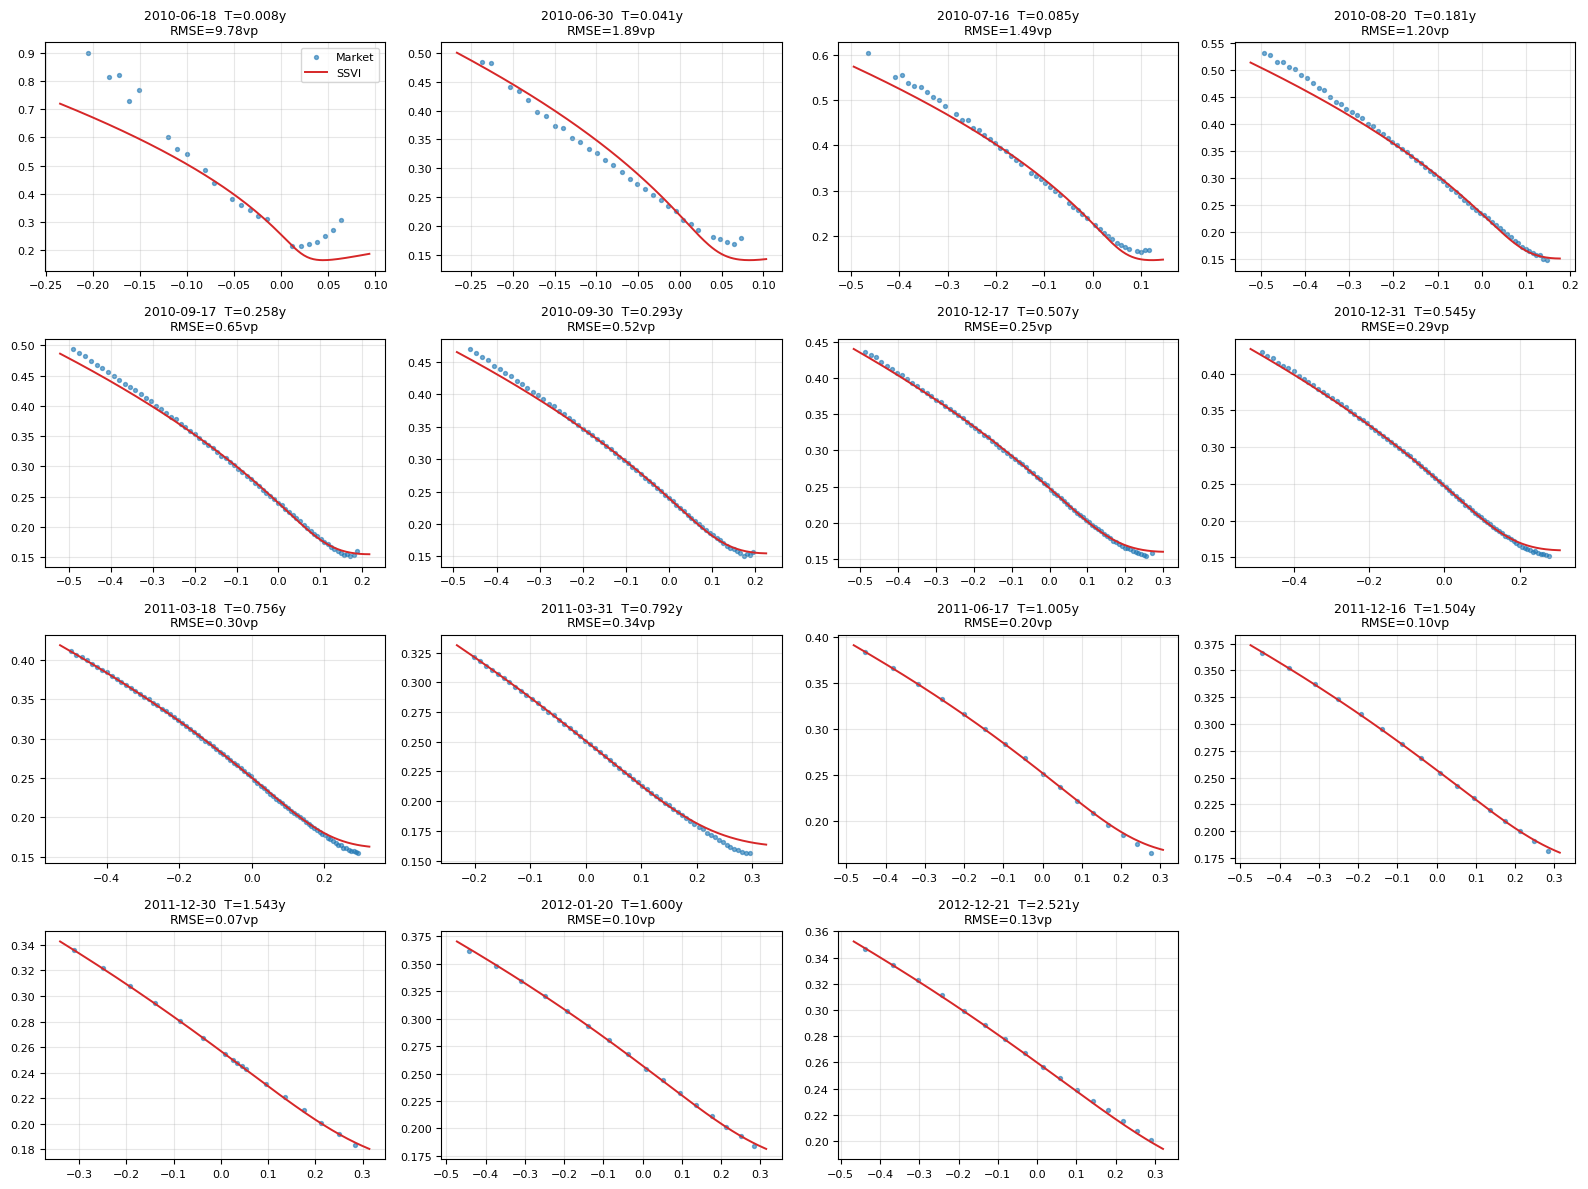

In [13]:
# ----------------------------------------------------------------
# 9. Visualisation: per-slice fits and 3D surface
# ----------------------------------------------------------------
expiries_by_T = sorted(snap.expiry.unique(),
                        key=lambda e: snap[snap.expiry == e].tau.iloc[0])
n_slices = len(expiries_by_T)
n_cols = 4
n_rows = (n_slices + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, expiry in enumerate(expiries_by_T):
    sdf = snap[snap.expiry == expiry].sort_values('k')
    T = float(sdf.tau.iloc[0])
    theta_row = atm_curve[atm_curve.expiry == expiry]
    if theta_row.empty: continue
    theta_t = float(theta_row.theta.iloc[0])
    k_g = np.linspace(sdf.k.min() - 0.03, sdf.k.max() + 0.03, 200)
    iv_ssvi = np.sqrt(ssvi_w(k_g, theta_t, ssvi_params) / T)

    ax = axes[i]
    ax.scatter(sdf.k, sdf.iv_mid, s=8, alpha=0.6, color='C0', label='Market')
    ax.plot(k_g, iv_ssvi, 'C3-', lw=1.4, label='SSVI')
    rmse = float(np.sqrt(np.mean((np.sqrt(ssvi_w(sdf.k.values, theta_t, ssvi_params) / T) - sdf.iv_mid.values) ** 2)))
    ax.set_title(f'{expiry.date()}  T={T:.3f}y\nRMSE={rmse*100:.2f}vp', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(); plt.show()

In [14]:
# ----------------------------------------------------------------
# 10. 3D SSVI surface plot
# ----------------------------------------------------------------
# theta(T) interpolated linearly between fitted maturities for visualisation.
theta_interp = interp1d(atm_curve['T'].values, atm_curve['theta'].values,
                         kind='linear', bounds_error=False,
                         fill_value=(atm_curve.theta.iloc[0], atm_curve.theta.iloc[-1]))

k_axis = np.linspace(-0.5, 0.3, 100)
T_axis = np.linspace(atm_curve['T'].min(), atm_curve['T'].max(), 80)
IV_grid = np.zeros((len(T_axis), len(k_axis)))
for i_T, T_val in enumerate(T_axis):
    theta_val = float(theta_interp(T_val))
    IV_grid[i_T] = np.sqrt(ssvi_w(k_axis, theta_val, ssvi_params) / T_val)

fig = go.Figure()
fig.add_trace(go.Surface(x=k_axis, y=T_axis, z=IV_grid,
                          colorscale='Viridis', colorbar=dict(title='IV'),
                          opacity=0.92,
                          contours={'z': {'show': True, 'usecolormap': True}}))
fig.add_trace(go.Scatter3d(x=snap.k, y=snap.tau, z=snap.iv_mid,
                            mode='markers',
                            marker=dict(size=2, color='black', opacity=0.5),
                            name='De-Americanised quotes'))
fig.update_layout(
    title=f'SPY SSVI surface, {SNAP_DATE}, '
          f'rho={ssvi_params.rho:.3f}, eta={ssvi_params.eta:.3f}, gamma={ssvi_params.gamma:.3f}',
    scene=dict(xaxis_title='k = log(K/F)', yaxis_title='T (years)',
                zaxis_title='Implied volatility',
                camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
                aspectratio=dict(x=1.2, y=1.2, z=0.8)),
    width=950, height=700, margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

In [15]:
# ----------------------------------------------------------------
# 11. ATM skew per maturity (for Phase 4 SSR groundwork)
# ----------------------------------------------------------------
# Analytic ATM skew of SSVI:
#   dw/dk at k=0  =  theta * phi * rho
#   dsigma/dk at k=0  =  rho * phi(theta) * sqrt(theta / T) / 2
# Persist per maturity. Used in Phase 4 SSR estimation across daily snapshots.

def ssvi_atm_skew(T, theta, p):
    """ATM skew dsigma/dk at k=0."""
    phi = phi_power_law(theta, p.eta, p.gamma)
    return p.rho * phi * np.sqrt(theta / T) / 2.0

skew_rows = []
for _, row in atm_curve.iterrows():
    sk = ssvi_atm_skew(row['T'], row.theta, ssvi_params)
    atm_iv = float(np.sqrt(row.theta / row['T']))
    skew_rows.append({
        'expiry': row.expiry, 'T': row['T'], 'theta': row.theta,
        'atm_iv': atm_iv, 'atm_skew': sk,
    })

skew_df = pd.DataFrame(skew_rows)
print('ATM skew term structure (SSVI):')
print(skew_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

ATM skew term structure (SSVI):
    expiry        T    theta   atm_iv  atm_skew
2010-06-18 0.008219 0.000535 0.255080 -3.328281
2010-06-30 0.041096 0.001969 0.218908 -1.533191
2010-07-16 0.084932 0.004402 0.227652 -1.086165
2010-08-20 0.180822 0.009872 0.233651 -0.758182
2010-09-17 0.257534 0.014753 0.239347 -0.641129
2010-09-30 0.293151 0.016823 0.239557 -0.602717
2010-12-17 0.506959 0.031130 0.247801 -0.464776
2010-12-31 0.545315 0.033288 0.247068 -0.448815
2011-03-18 0.756164 0.047416 0.250411 -0.384214
2011-03-31 0.791781 0.049752 0.250671 -0.375884
2011-06-17 1.005479 0.064024 0.252339 -0.335473
2011-12-16 1.504219 0.099396 0.257057 -0.277031
2011-12-30 1.542575 0.101896 0.257013 -0.273720
2012-01-20 1.600110 0.105772 0.257105 -0.268982
2012-12-21 2.520658 0.170249 0.259887 -0.216639


In [16]:
# ----------------------------------------------------------------
# 12. SSVISurface class
# ----------------------------------------------------------------
class SSVISurface:
    """Phase 2 surface: SSVI with ATM term structure."""

    def __init__(self, params, atm_curve, S, snapshot_date):
        self.params = params
        self.atm = atm_curve.copy()
        self.S = S
        self.snapshot_date = snapshot_date
        self._theta = interp1d(
            atm_curve['T'].values, atm_curve['theta'].values,
            kind='linear', bounds_error=False,
            fill_value=(atm_curve.theta.iloc[0], atm_curve.theta.iloc[-1]),
        )

    def theta(self, T):
        return float(self._theta(T))

    def total_variance(self, k, T):
        return ssvi_w(np.asarray(k), self.theta(T), self.params)

    def iv(self, k, T):
        return np.sqrt(self.total_variance(k, T) / T)

    def density(self, k, T):
        theta_t = self.theta(T)
        w = ssvi_w(k, theta_t, self.params)
        g = ssvi_durrleman_g(k, theta_t, self.params)
        d2 = -k / np.sqrt(w) - np.sqrt(w) / 2
        return g * np.exp(-d2 ** 2 / 2) / np.sqrt(2 * np.pi * w)

    def atm_skew(self, T):
        return ssvi_atm_skew(T, self.theta(T), self.params)

    def __repr__(self):
        return (f'<SSVISurface date={self.snapshot_date} '
                f'rho={self.params.rho:+.3f} eta={self.params.eta:.3f} '
                f'gamma={self.params.gamma:.3f}>')

surface = SSVISurface(ssvi_params, atm_curve, S=float(snap.S.iloc[0]),
                      snapshot_date=pd.Timestamp(SNAP_DATE))
print(repr(surface))
print(f'  ATM IV(T=0.25): {surface.iv(0.0, 0.25):.4f}')
print(f'  ATM IV(T=0.50): {surface.iv(0.0, 0.50):.4f}')
print(f'  ATM IV(T=1.00): {surface.iv(0.0, 1.00):.4f}')
print(f'  ATM skew(T=0.25): {surface.atm_skew(0.25):+.4f}')
print(f'  ATM skew(T=1.00): {surface.atm_skew(1.00):+.4f}')

<SSVISurface date=2010-06-15 00:00:00 rho=-0.764 eta=0.938 gamma=0.477>
  ATM IV(T=0.25): 0.2389
  ATM IV(T=0.50): 0.2476
  ATM IV(T=1.00): 0.2523
  ATM skew(T=0.25): -0.6502
  ATM skew(T=1.00): -0.3363


In [17]:
# ----------------------------------------------------------------
# 13. Persist
# ----------------------------------------------------------------
# Two parquet files: SSVI parameters and the ATM theta_T curve.

ssvi_params_df = pd.DataFrame([{
    'date': pd.Timestamp(SNAP_DATE),
    'rho': ssvi_params.rho,
    'eta': ssvi_params.eta,
    'gamma': ssvi_params.gamma,
    'loss': float(res.fun),
    'success': bool(res.success),
    'n_iter': int(res.nit),
    'n_quotes': int(len(snap)),
}])
params_path = FITTED_DIR / f'ssvi_params_{SNAP_DATE}.parquet'
ssvi_params_df.to_parquet(params_path)

atm_path = FITTED_DIR / f'ssvi_atm_{SNAP_DATE}.parquet'
atm_curve.to_parquet(atm_path)

print(f'Saved: {params_path}')
print(f'Saved: {atm_path}')
print(f'Skew per maturity saved separately if needed:')
print(skew_df.head())

Saved: /content/drive/MyDrive/Vol_fitter/data_fitted/ssvi_params_2010-06-15.parquet
Saved: /content/drive/MyDrive/Vol_fitter/data_fitted/ssvi_atm_2010-06-15.parquet
Skew per maturity saved separately if needed:
      expiry         T     theta    atm_iv  atm_skew
0 2010-06-18  0.008219  0.000535  0.255080 -3.328281
1 2010-06-30  0.041096  0.001969  0.218908 -1.533191
2 2010-07-16  0.084932  0.004402  0.227652 -1.086165
3 2010-08-20  0.180822  0.009872  0.233651 -0.758182
4 2010-09-17  0.257534  0.014753  0.239347 -0.641129


# Part 2

In [18]:
# ----------------------------------------------------------------
# 14. xSSVI parameterisation (per-maturity rho, shared eta, gamma)
# ----------------------------------------------------------------
# Same SSVI formula, but rho can be a scalar or an array broadcasting
# against k and theta. This lets one function serve per-quote evaluation
# (rho array) and per-slice evaluation (rho scalar).

def xssvi_w(k, theta, rho, eta, gamma):
    """SSVI total variance, generalised to support array rho."""
    phi = eta * np.power(theta, -gamma)
    z = phi * k
    return 0.5 * theta * (1.0 + rho * z + np.sqrt((z + rho) ** 2 + 1.0 - rho ** 2))

def xssvi_dw_dk(k, theta, rho, eta, gamma):
    phi = eta * np.power(theta, -gamma)
    z = phi * k
    inner_root = np.sqrt((z + rho) ** 2 + 1.0 - rho ** 2)
    return 0.5 * theta * phi * (rho + (z + rho) / inner_root)

def xssvi_d2w_dk2(k, theta, rho, eta, gamma):
    phi = eta * np.power(theta, -gamma)
    z = phi * k
    denom = np.power((z + rho) ** 2 + 1.0 - rho ** 2, 1.5)
    return 0.5 * theta * (phi ** 2) * (1.0 - rho ** 2) / denom

def xssvi_durrleman_g(k, theta, rho, eta, gamma):
    w = xssvi_w(k, theta, rho, eta, gamma)
    wp = xssvi_dw_dk(k, theta, rho, eta, gamma)
    wpp = xssvi_d2w_dk2(k, theta, rho, eta, gamma)
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2

# Smoke test: at k=0 with any rho, w should equal theta exactly
for rho_t in (-0.9, -0.5, -0.1):
    w0 = xssvi_w(0.0, 0.05, rho_t, 1.0, 0.3)
    assert abs(w0 - 0.05) < 1e-10, f'xssvi_w(0,...) failed for rho={rho_t}'
print('xSSVI smoke test passed: w(k=0, theta) = theta for all rho')

xSSVI smoke test passed: w(k=0, theta) = theta for all rho


In [19]:
# ----------------------------------------------------------------
# 15. xSSVI calibrator
# ----------------------------------------------------------------
# Vector parameter [eta, gamma, rho_1, ..., rho_N]. Vector-valued ineq
# constraints to SLSQP: one butterfly vector (length 2N), one calendar
# vector (length (N-1) * len(k_grid)). Warm-started from SSVI.

def fit_xssvi_surface(snap, atm_curve, ssvi_init,
                     weights='vega',
                     n_cal_grid=25, k_cal_range=(-0.5, 0.3),
                     verbose=False):
    # Sort atm curve and tag each maturity with integer index
    sorted_atm = atm_curve.sort_values('T').reset_index(drop=True).copy()
    sorted_atm['mat_idx'] = np.arange(len(sorted_atm))
    Ts = sorted_atm['T'].values
    thetas = sorted_atm.theta.values
    N = len(Ts)

    # Join snap quotes to maturity index and theta
    snap_join = snap.merge(sorted_atm[['expiry', 'theta', 'mat_idx']],
                            on='expiry', how='left')
    snap_join = snap_join[snap_join.theta.notna()].reset_index(drop=True)

    quote_idx = snap_join.mat_idx.values.astype(int)
    k_arr = snap_join.k.values
    theta_arr = snap_join.theta.values
    T_arr = snap_join.tau.values
    iv_market = snap_join.iv_mid.values

    if weights == 'vega':
        vega = bs_vega(snap_join.S.values, snap_join.strike.values, T_arr,
                       snap_join.r.values, snap_join.q.values, iv_market)
        w_quote = np.where(np.isfinite(vega) & (vega > 1e-6), vega, 0.0)
    elif weights == 'uniform':
        w_quote = np.ones_like(k_arr)
    else:
        raise ValueError(f'unknown weights: {weights}')

    k_cal_grid = np.linspace(k_cal_range[0], k_cal_range[1], n_cal_grid)

    def loss(params):
        eta = params[0]; gamma = params[1]; rhos = params[2:]
        rho_per_quote = rhos[quote_idx]
        phi = eta * np.power(theta_arr, -gamma)
        z = phi * k_arr
        w_model = 0.5 * theta_arr * (1.0 + rho_per_quote * z +
                    np.sqrt((z + rho_per_quote) ** 2 + 1.0 - rho_per_quote ** 2))
        w_model = np.clip(w_model, 1e-10, None)
        iv_model = np.sqrt(w_model / T_arr)
        return float(np.sum((w_quote ** 2) * (iv_model - iv_market) ** 2))

    def butterfly_constraint_vec(params):
        eta = params[0]; gamma = params[1]; rhos = params[2:]
        phi = eta * np.power(thetas, -gamma)
        abs_rho_factor = 1.0 + np.abs(rhos)
        c1 = 4.0 - thetas * phi * abs_rho_factor - 0.01
        c2 = 4.0 - thetas * (phi ** 2) * abs_rho_factor
        return np.concatenate([c1, c2])

    def calendar_constraint_vec(params):
        eta = params[0]; gamma = params[1]; rhos = params[2:]
        THETA = thetas[:, None]
        PHI = eta * np.power(THETA, -gamma)
        RHO = rhos[:, None]
        Z = PHI * k_cal_grid[None, :]
        W = 0.5 * THETA * (1.0 + RHO * Z + np.sqrt((Z + RHO) ** 2 + 1.0 - RHO ** 2))
        diffs = W[1:, :] - W[:-1, :]
        return diffs.flatten()

    constraints = [
        {'type': 'ineq', 'fun': butterfly_constraint_vec},
        {'type': 'ineq', 'fun': calendar_constraint_vec},
    ]
    bounds = [(0.01, 20.0), (0.01, 0.95)] + [(-0.999, -0.01)] * N

    x0 = np.concatenate([
        [ssvi_init.eta, ssvi_init.gamma],
        np.full(N, ssvi_init.rho)
    ])

    res = minimize(loss, x0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 500, 'disp': verbose})

    return {
        'eta': float(res.x[0]),
        'gamma': float(res.x[1]),
        'rhos': res.x[2:].copy(),
        'Ts': Ts.copy(),
        'thetas': thetas.copy(),
        'expiries': list(sorted_atm.expiry),
        'sorted_atm': sorted_atm,
        'result': res,
    }

In [20]:
# ----------------------------------------------------------------
# 16. Fit xSSVI and report
# ----------------------------------------------------------------
import time
t0 = time.time()
xssvi = fit_xssvi_surface(snap_clean, atm_clean, ssvi_init=ssvi_clean,
                          weights='vega', verbose=False)
elapsed = time.time() - t0

print(f'xSSVI fit in {elapsed:.2f}s')
print(f'  eta   = {xssvi["eta"]:.4f}  (SSVI was {ssvi_clean.eta:.4f})')
print(f'  gamma = {xssvi["gamma"]:.4f}  (SSVI was {ssvi_clean.gamma:.4f})')
print(f'  converged: {xssvi["result"].success}')
print(f'  message: {xssvi["result"].message}')
print(f'  iterations: {xssvi["result"].nit}')
print(f'  final loss: {xssvi["result"].fun:.4e}  (SSVI loss was {res_clean.fun:.4e})')

print(f'\nPer-maturity rho:')
print(f'{"T":>8} {"rho_xssvi":>12} {"rho_ssvi":>10} {"delta":>10}')
for T, rho_x in zip(xssvi['Ts'], xssvi['rhos']):
    delta = rho_x - ssvi_clean.rho
    print(f'{T:>8.4f} {rho_x:>+12.4f} {ssvi_clean.rho:>+10.4f} {delta:>+10.4f}')

xSSVI fit in 0.15s
  eta   = 0.9024  (SSVI was 0.9373)
  gamma = 0.4903  (SSVI was 0.4774)
  converged: True
  message: Optimization terminated successfully
  iterations: 23
  final loss: 5.3053e-01  (SSVI loss was 8.1199e-01)

Per-maturity rho:
       T    rho_xssvi   rho_ssvi      delta
  0.0411      -0.5313    -0.7637    +0.2324
  0.0849      -0.6595    -0.7637    +0.1042
  0.1808      -0.7281    -0.7637    +0.0356
  0.2575      -0.7468    -0.7637    +0.0169
  0.2932      -0.7548    -0.7637    +0.0089
  0.5070      -0.7605    -0.7637    +0.0032
  0.5453      -0.7633    -0.7637    +0.0004
  0.7562      -0.7712    -0.7637    -0.0075
  0.7918      -0.7679    -0.7637    -0.0041
  1.0055      -0.7756    -0.7637    -0.0118
  1.5042      -0.7727    -0.7637    -0.0090
  1.5426      -0.7659    -0.7637    -0.0022
  1.6001      -0.7659    -0.7637    -0.0022
  2.5207      -0.7569    -0.7637    +0.0068


In [21]:
# ----------------------------------------------------------------
# 17. Three-way comparison: SVI vs SSVI vs xSSVI on same clean data
# ----------------------------------------------------------------
# Vega-weighted RMSE per slice (the metric SSVI and xSSVI were
# optimising). Same merged dataset, same weights, same quotes.

snap_x = snap_clean.merge(xssvi['sorted_atm'][['expiry', 'theta', 'mat_idx']],
                          on='expiry', how='left')
snap_x = snap_x[snap_x.theta.notna()].reset_index(drop=True)

rows = []
for expiry, g in snap_x.groupby('expiry'):
    sdf = g.sort_values('k').reset_index(drop=True)
    T = float(sdf.tau.iloc[0])
    theta_t = float(sdf.theta.iloc[0])
    rho_t = float(xssvi['rhos'][int(sdf.mat_idx.iloc[0])])

    vega = bs_vega(sdf.S.values, sdf.strike.values, sdf.tau.values,
                   sdf.r.values, sdf.q.values, sdf.iv_mid.values)
    ok = np.isfinite(vega) & (vega > 0)
    if not ok.any(): continue
    iv_mkt = sdf.iv_mid.values[ok]
    v = vega[ok]
    k_ok = sdf.k.values[ok]

    iv_svi = np.sqrt(svi_w_fn(k_ok, svi_by_expiry[expiry]) / T)
    iv_ssvi = np.sqrt(ssvi_w(k_ok, theta_t, ssvi_clean) / T)
    iv_xssvi = np.sqrt(xssvi_w(k_ok, theta_t, rho_t, xssvi['eta'], xssvi['gamma']) / T)

    _, svi_vw = both_rmse(iv_svi, iv_mkt, v)
    _, ssvi_vw = both_rmse(iv_ssvi, iv_mkt, v)
    _, xssvi_vw = both_rmse(iv_xssvi, iv_mkt, v)

    rows.append({
        'T': T, 'n': int(ok.sum()),
        'svi_vw_vp': svi_vw * 100,
        'ssvi_vw_vp': ssvi_vw * 100,
        'xssvi_vw_vp': xssvi_vw * 100,
    })

compare3 = pd.DataFrame(rows).sort_values('T').reset_index(drop=True)
print('Vega-weighted RMSE in vol points:')
print(compare3.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

n_total = compare3.n.sum()
print(f'\nQuote-weighted means:')
for col, lbl in [('svi_vw_vp', 'SVI  '), ('ssvi_vw_vp', 'SSVI '), ('xssvi_vw_vp', 'xSSVI')]:
    wmean = float((compare3[col] * compare3.n).sum() / n_total)
    print(f'  {lbl}: {wmean:.3f} vp')

Vega-weighted RMSE in vol points:
    T  n  svi_vw_vp  ssvi_vw_vp  xssvi_vw_vp
0.041 31      0.487       1.240        0.448
0.085 48      0.213       0.638        0.284
0.181 62      0.116       0.409        0.362
0.258 67      0.097       0.253        0.237
0.293 66      0.083       0.194        0.179
0.507 77      0.076       0.102        0.101
0.545 79      0.055       0.104        0.097
0.756 82      0.051       0.102        0.085
0.792 59      0.031       0.104        0.100
1.005 16      0.055       0.102        0.066
1.504 16      0.056       0.077        0.074
1.543 17      0.025       0.059        0.058
1.600 16      0.054       0.082        0.076
2.521 16      0.068       0.139        0.117

Quote-weighted means:
  SVI  : 0.100 vp
  SSVI : 0.249 vp
  xSSVI: 0.172 vp


In [22]:
# ----------------------------------------------------------------
# 18. xSSVI arbitrage diagnostics
# ----------------------------------------------------------------
# Should be clean by construction: butterfly constraints in the
# calibration plus calendar constraints on the k grid. Verify.

print('xSSVI butterfly check (g(k) >= 0 on k in [-3, 3]):')
print(f'{"T":>8} {"theta":>10} {"rho":>8} {"g_min":>14} {"n_violations":>14}')
k_check = np.linspace(-3.0, 3.0, 1000)
for i in range(len(xssvi['Ts'])):
    g = xssvi_durrleman_g(k_check, xssvi['thetas'][i], xssvi['rhos'][i],
                           xssvi['eta'], xssvi['gamma'])
    g_min = float(g.min())
    n_viol = int((g < -1e-6).sum())
    print(f'{xssvi["Ts"][i]:>8.4f} {xssvi["thetas"][i]:>10.6f} '
          f'{xssvi["rhos"][i]:>+8.3f} {g_min:>+14.4e} {n_viol:>14d}')

print('\nxSSVI calendar check (adjacent slices, k in [-0.5, 0.3], 200 pts):')
k_cal = np.linspace(-0.5, 0.3, 200)
issues = []
for i in range(len(xssvi['Ts']) - 1):
    w_lo = xssvi_w(k_cal, xssvi['thetas'][i], xssvi['rhos'][i],
                    xssvi['eta'], xssvi['gamma'])
    w_hi = xssvi_w(k_cal, xssvi['thetas'][i+1], xssvi['rhos'][i+1],
                    xssvi['eta'], xssvi['gamma'])
    xings = int((w_hi < w_lo - 1e-8).sum())
    if xings > 0:
        issues.append((xssvi['Ts'][i], xssvi['Ts'][i+1], xings))
        print(f'  T={xssvi["Ts"][i]:.4f} -> T={xssvi["Ts"][i+1]:.4f}: {xings} crossings')

if not issues:
    print('  Clean.')

xSSVI butterfly check (g(k) >= 0 on k in [-3, 3]):
       T      theta      rho          g_min   n_violations
  0.0411   0.001969   -0.531    +2.5629e-01              0
  0.0849   0.004402   -0.659    +2.5890e-01              0
  0.1808   0.009872   -0.728    +2.6273e-01              0
  0.2575   0.014753   -0.747    +2.6525e-01              0
  0.2932   0.016823   -0.755    +2.6616e-01              0
  0.5070   0.031130   -0.761    +2.7137e-01              0
  0.5453   0.033288   -0.763    +2.7200e-01              0
  0.7562   0.047416   -0.771    +2.7569e-01              0
  0.7918   0.049752   -0.768    +2.7628e-01              0
  1.0055   0.064024   -0.776    +2.7925e-01              0
  1.5042   0.099396   -0.773    +2.8539e-01              0
  1.5426   0.101896   -0.766    +2.8591e-01              0
  1.6001   0.105772   -0.766    +2.8648e-01              0
  2.5207   0.170249   -0.757    +2.9463e-01              0

xSSVI calendar check (adjacent slices, k in [-0.5, 0.3], 200 pt

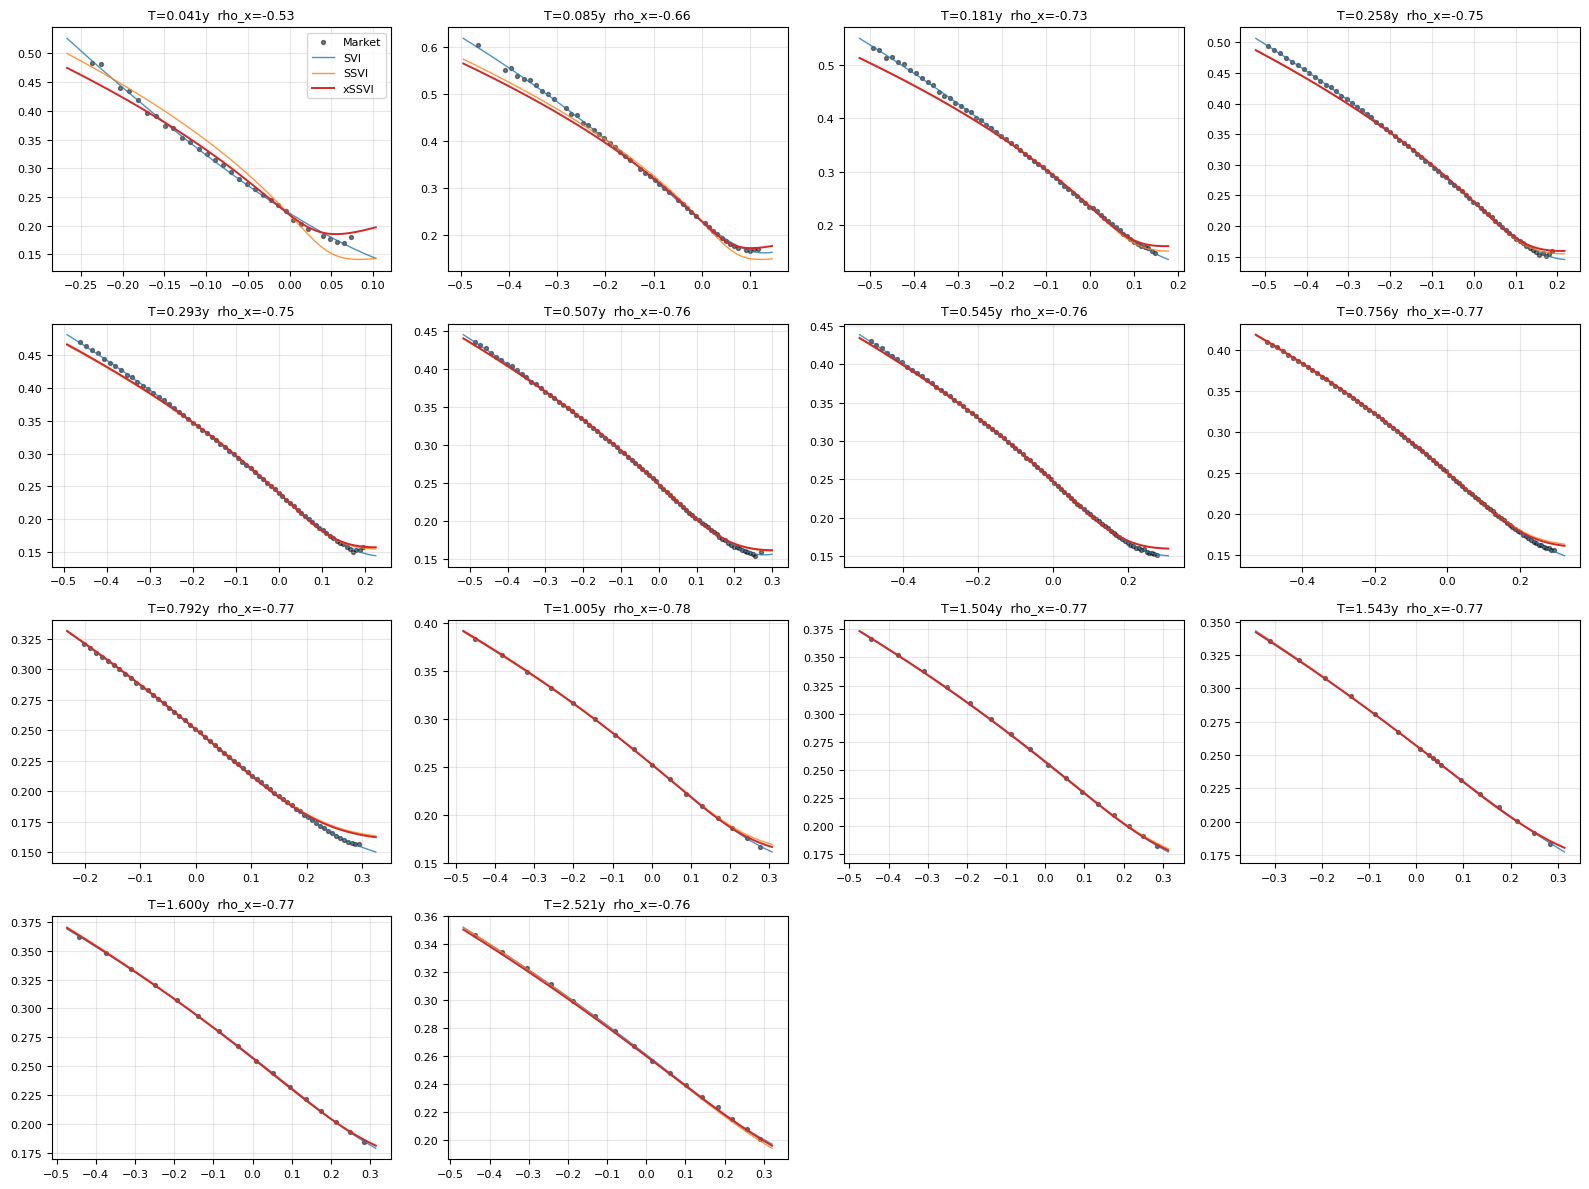

In [23]:
# ----------------------------------------------------------------
# 19. Per-slice fit visualisation (SVI vs SSVI vs xSSVI)
# ----------------------------------------------------------------
expiries_by_T = sorted(snap_clean.expiry.unique(),
                        key=lambda e: snap_clean[snap_clean.expiry == e].tau.iloc[0])
n_slices = len(expiries_by_T)
n_cols = 4
n_rows = (n_slices + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

expiry_to_xidx = dict(zip(xssvi['expiries'], range(len(xssvi['expiries']))))

for i, expiry in enumerate(expiries_by_T):
    sdf = snap_clean[snap_clean.expiry == expiry].sort_values('k')
    T = float(sdf.tau.iloc[0])
    theta_t = float(atm_clean[atm_clean.expiry == expiry].theta.iloc[0])
    rho_t = xssvi['rhos'][expiry_to_xidx[expiry]]

    k_g = np.linspace(sdf.k.min() - 0.03, sdf.k.max() + 0.03, 200)
    iv_svi = np.sqrt(svi_w_fn(k_g, svi_by_expiry[expiry]) / T)
    iv_ssvi = np.sqrt(ssvi_w(k_g, theta_t, ssvi_clean) / T)
    iv_xssvi = np.sqrt(xssvi_w(k_g, theta_t, rho_t, xssvi['eta'], xssvi['gamma']) / T)

    ax = axes[i]
    ax.scatter(sdf.k, sdf.iv_mid, s=8, alpha=0.5, color='black', label='Market')
    ax.plot(k_g, iv_svi, 'C0-', lw=1, label='SVI', alpha=0.8)
    ax.plot(k_g, iv_ssvi, 'C1-', lw=1, label='SSVI', alpha=0.8)
    ax.plot(k_g, iv_xssvi, 'C3-', lw=1.4, label='xSSVI')
    ax.set_title(f'T={T:.3f}y  rho_x={rho_t:+.2f}', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(); plt.show()

In [24]:
# ----------------------------------------------------------------
# 20. Persist xSSVI fit
# ----------------------------------------------------------------
xssvi_rows = []
for i, (T, theta, rho_t, expiry) in enumerate(zip(
        xssvi['Ts'], xssvi['thetas'], xssvi['rhos'], xssvi['expiries'])):
    xssvi_rows.append({
        'date': pd.Timestamp(SNAP_DATE),
        'expiry': expiry, 'T': T, 'theta': theta, 'rho': rho_t,
        'eta_shared': xssvi['eta'], 'gamma_shared': xssvi['gamma'],
    })
xssvi_df = pd.DataFrame(xssvi_rows)

xssvi_path = FITTED_DIR / f'xssvi_{SNAP_DATE}.parquet'
xssvi_df.to_parquet(xssvi_path)
print(f'Saved: {xssvi_path}')
print(xssvi_df[['T', 'theta', 'rho', 'eta_shared', 'gamma_shared']].to_string(
    index=False, float_format=lambda x: f'{x:.4f}'))

Saved: /content/drive/MyDrive/Vol_fitter/data_fitted/xssvi_2010-06-15.parquet
     T  theta     rho  eta_shared  gamma_shared
0.0411 0.0020 -0.5313      0.9024        0.4903
0.0849 0.0044 -0.6595      0.9024        0.4903
0.1808 0.0099 -0.7281      0.9024        0.4903
0.2575 0.0148 -0.7468      0.9024        0.4903
0.2932 0.0168 -0.7548      0.9024        0.4903
0.5070 0.0311 -0.7605      0.9024        0.4903
0.5453 0.0333 -0.7633      0.9024        0.4903
0.7562 0.0474 -0.7712      0.9024        0.4903
0.7918 0.0498 -0.7679      0.9024        0.4903
1.0055 0.0640 -0.7756      0.9024        0.4903
1.5042 0.0994 -0.7727      0.9024        0.4903
1.5426 0.1019 -0.7659      0.9024        0.4903
1.6001 0.1058 -0.7659      0.9024        0.4903
2.5207 0.1702 -0.7569      0.9024        0.4903


In [25]:
# ----------------------------------------------------------------
# Promote SSVI and xSSVI to volsurf/parametric_ssvi.py
# ----------------------------------------------------------------
PARAMETRIC_SSVI_PY = r'''"""SSVI and xSSVI parametric volatility surfaces (Phase 2).

SSVI: Gatheral-Jacquier (2014). Three parameters (rho, eta, gamma) plus an
ATM total variance term structure theta_T inferred from the data. Calendar
arbitrage-free by construction (theta monotone in T). Butterfly arbitrage-
free under explicit parameter constraints enforced via SLSQP.

xSSVI: per-maturity rho with shared (eta, gamma). Captures the documented
term structure of equity skew. Same calendar and butterfly arbitrage
guarantees via vector-valued SLSQP constraints across adjacent slices.

References:
    Gatheral, J. and Jacquier, A. (2014). Arbitrage-free SVI volatility
    surfaces. Quantitative Finance 14(1), 59-71.
    Hendriks, S. and Martini, C. (2017). The extended SSVI volatility
    surface. SSRN 2971502.
"""
from __future__ import annotations
from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.interpolate import interp1d

from .pricing import bs_vega


# ----------------------------------------------------------------
# SSVI parameterisation
# ----------------------------------------------------------------

@dataclass(frozen=True)
class SSVIParams:
    rho: float
    eta: float
    gamma: float


def phi_power_law(theta, eta, gamma):
    return eta * np.power(theta, -gamma)


def ssvi_w(k, theta, p):
    phi = phi_power_law(theta, p.eta, p.gamma)
    z = phi * k
    return 0.5 * theta * (1.0 + p.rho * z + np.sqrt((z + p.rho) ** 2 + (1.0 - p.rho ** 2)))


def ssvi_dw_dk(k, theta, p):
    phi = phi_power_law(theta, p.eta, p.gamma)
    z = phi * k
    inner_root = np.sqrt((z + p.rho) ** 2 + (1.0 - p.rho ** 2))
    return 0.5 * theta * phi * (p.rho + (z + p.rho) / inner_root)


def ssvi_d2w_dk2(k, theta, p):
    phi = phi_power_law(theta, p.eta, p.gamma)
    z = phi * k
    denom = np.power((z + p.rho) ** 2 + (1.0 - p.rho ** 2), 1.5)
    return 0.5 * theta * (phi ** 2) * (1.0 - p.rho ** 2) / denom


def ssvi_iv(k, T, theta, p):
    return np.sqrt(ssvi_w(k, theta, p) / T)


def ssvi_durrleman_g(k, theta, p):
    w = ssvi_w(k, theta, p)
    wp = ssvi_dw_dk(k, theta, p)
    wpp = ssvi_d2w_dk2(k, theta, p)
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2


def ssvi_atm_skew(T, theta, p):
    phi = phi_power_law(theta, p.eta, p.gamma)
    return p.rho * phi * np.sqrt(theta / T) / 2.0


# ----------------------------------------------------------------
# xSSVI parameterisation (per-maturity rho)
# ----------------------------------------------------------------

def xssvi_w(k, theta, rho, eta, gamma):
    phi = eta * np.power(theta, -gamma)
    z = phi * k
    return 0.5 * theta * (1.0 + rho * z + np.sqrt((z + rho) ** 2 + 1.0 - rho ** 2))


def xssvi_dw_dk(k, theta, rho, eta, gamma):
    phi = eta * np.power(theta, -gamma)
    z = phi * k
    inner_root = np.sqrt((z + rho) ** 2 + 1.0 - rho ** 2)
    return 0.5 * theta * phi * (rho + (z + rho) / inner_root)


def xssvi_d2w_dk2(k, theta, rho, eta, gamma):
    phi = eta * np.power(theta, -gamma)
    z = phi * k
    denom = np.power((z + rho) ** 2 + 1.0 - rho ** 2, 1.5)
    return 0.5 * theta * (phi ** 2) * (1.0 - rho ** 2) / denom


def xssvi_durrleman_g(k, theta, rho, eta, gamma):
    w = xssvi_w(k, theta, rho, eta, gamma)
    wp = xssvi_dw_dk(k, theta, rho, eta, gamma)
    wpp = xssvi_d2w_dk2(k, theta, rho, eta, gamma)
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2


# ----------------------------------------------------------------
# ATM theta_T term structure
# ----------------------------------------------------------------

def build_atm_theta_curve(snap, k_window=0.1):
    """ATM total variance per maturity by local quadratic. Requires
    columns: expiry, k, w, tau. Enforces monotonicity in T."""
    rows = []
    for expiry, slice_df in snap.groupby('expiry'):
        sdf = slice_df.sort_values('k').reset_index(drop=True)
        near = sdf[sdf.k.between(-k_window, k_window)]
        if len(near) >= 3:
            coeffs = np.polyfit(near.k.values, near.w.values, 2)
            theta = float(np.polyval(coeffs, 0.0))
        elif len(sdf) >= 1:
            i_nearest = int(sdf.k.abs().idxmin())
            theta = float(sdf.loc[i_nearest, 'w'])
        else:
            continue
        T = float(sdf.tau.iloc[0])
        rows.append({'expiry': expiry, 'T': T, 'theta_raw': theta, 'n_near': len(near)})

    atm = pd.DataFrame(rows).sort_values('T').reset_index(drop=True)
    atm['theta'] = np.maximum.accumulate(atm.theta_raw.values)
    atm['theta_adjusted'] = atm.theta != atm.theta_raw
    return atm


# ----------------------------------------------------------------
# SSVI calibration
# ----------------------------------------------------------------

def fit_ssvi_surface(snap, atm_curve, weights='vega',
                     rho_init=-0.6, eta_init=1.0, gamma_init=0.3,
                     verbose=False):
    """Fit SSVI to a full surface via SLSQP."""
    snap_ = snap.merge(atm_curve[['expiry', 'theta']], on='expiry', how='left')
    snap_ = snap_[snap_.theta.notna()].reset_index(drop=True)

    k_arr = snap_.k.values
    theta_arr = snap_.theta.values
    T_arr = snap_.tau.values
    iv_market = snap_.iv_mid.values

    if weights == 'vega':
        v = bs_vega(snap_.S.values, snap_.strike.values, T_arr,
                    snap_.r.values, snap_.q.values, iv_market)
        w_quote = np.where(np.isfinite(v) & (v > 1e-6), v, 0.0)
    elif weights == 'uniform':
        w_quote = np.ones_like(k_arr)
    else:
        raise ValueError(f'unknown weights option: {weights}')

    theta_min = float(atm_curve.theta.min())
    theta_max = float(atm_curve.theta.max())

    def loss(params):
        rho, eta, gamma = params
        p = SSVIParams(rho=float(rho), eta=float(eta), gamma=float(gamma))
        w_model = ssvi_w(k_arr, theta_arr, p)
        w_model = np.clip(w_model, 1e-10, None)
        iv_model = np.sqrt(w_model / T_arr)
        return float(np.sum((w_quote ** 2) * (iv_model - iv_market) ** 2))

    def butterfly_1(params, theta_val):
        rho, eta, gamma = params
        phi = eta * np.power(theta_val, -gamma)
        return 4.0 - theta_val * phi * (1.0 + abs(rho)) - 0.01

    def butterfly_2(params, theta_val):
        rho, eta, gamma = params
        phi = eta * np.power(theta_val, -gamma)
        return 4.0 - theta_val * (phi ** 2) * (1.0 + abs(rho))

    constraints = []
    for tv in (theta_min, theta_max):
        constraints.append({'type': 'ineq', 'fun': butterfly_1, 'args': (tv,)})
        constraints.append({'type': 'ineq', 'fun': butterfly_2, 'args': (tv,)})

    bounds = [(-0.999, -0.01), (0.01, 20.0), (0.01, 0.95)]

    res = minimize(loss, [rho_init, eta_init, gamma_init],
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 300, 'disp': verbose})

    params = SSVIParams(rho=float(res.x[0]), eta=float(res.x[1]), gamma=float(res.x[2]))
    return params, res


# ----------------------------------------------------------------
# xSSVI calibration
# ----------------------------------------------------------------

def fit_xssvi_surface(snap, atm_curve, ssvi_init,
                      weights='vega',
                      n_cal_grid=25, k_cal_range=(-0.5, 0.3),
                      verbose=False):
    """Fit xSSVI: per-maturity rho, shared (eta, gamma).

    ssvi_init is an SSVIParams used as warm start. Returns dict including
    the fitted parameters and the sorted ATM curve.
    """
    sorted_atm = atm_curve.sort_values('T').reset_index(drop=True).copy()
    sorted_atm['mat_idx'] = np.arange(len(sorted_atm))
    Ts = sorted_atm['T'].values
    thetas = sorted_atm.theta.values
    N = len(Ts)

    snap_join = snap.merge(sorted_atm[['expiry', 'theta', 'mat_idx']],
                           on='expiry', how='left')
    snap_join = snap_join[snap_join.theta.notna()].reset_index(drop=True)

    quote_idx = snap_join.mat_idx.values.astype(int)
    k_arr = snap_join.k.values
    theta_arr = snap_join.theta.values
    T_arr = snap_join.tau.values
    iv_market = snap_join.iv_mid.values

    if weights == 'vega':
        v = bs_vega(snap_join.S.values, snap_join.strike.values, T_arr,
                    snap_join.r.values, snap_join.q.values, iv_market)
        w_quote = np.where(np.isfinite(v) & (v > 1e-6), v, 0.0)
    elif weights == 'uniform':
        w_quote = np.ones_like(k_arr)
    else:
        raise ValueError(f'unknown weights: {weights}')

    k_cal_grid = np.linspace(k_cal_range[0], k_cal_range[1], n_cal_grid)

    def loss(params):
        eta = params[0]; gamma = params[1]; rhos = params[2:]
        rho_per_quote = rhos[quote_idx]
        phi = eta * np.power(theta_arr, -gamma)
        z = phi * k_arr
        w_model = 0.5 * theta_arr * (1.0 + rho_per_quote * z +
                    np.sqrt((z + rho_per_quote) ** 2 + 1.0 - rho_per_quote ** 2))
        w_model = np.clip(w_model, 1e-10, None)
        iv_model = np.sqrt(w_model / T_arr)
        return float(np.sum((w_quote ** 2) * (iv_model - iv_market) ** 2))

    def butterfly_constraint_vec(params):
        eta = params[0]; gamma = params[1]; rhos = params[2:]
        phi = eta * np.power(thetas, -gamma)
        abs_rho_factor = 1.0 + np.abs(rhos)
        c1 = 4.0 - thetas * phi * abs_rho_factor - 0.01
        c2 = 4.0 - thetas * (phi ** 2) * abs_rho_factor
        return np.concatenate([c1, c2])

    def calendar_constraint_vec(params):
        eta = params[0]; gamma = params[1]; rhos = params[2:]
        THETA = thetas[:, None]
        PHI = eta * np.power(THETA, -gamma)
        RHO = rhos[:, None]
        Z = PHI * k_cal_grid[None, :]
        W = 0.5 * THETA * (1.0 + RHO * Z + np.sqrt((Z + RHO) ** 2 + 1.0 - RHO ** 2))
        diffs = W[1:, :] - W[:-1, :]
        return diffs.flatten()

    constraints = [
        {'type': 'ineq', 'fun': butterfly_constraint_vec},
        {'type': 'ineq', 'fun': calendar_constraint_vec},
    ]
    bounds = [(0.01, 20.0), (0.01, 0.95)] + [(-0.999, -0.01)] * N

    x0 = np.concatenate([
        [ssvi_init.eta, ssvi_init.gamma],
        np.full(N, ssvi_init.rho)
    ])

    res = minimize(loss, x0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 500, 'disp': verbose})

    return {
        'eta': float(res.x[0]),
        'gamma': float(res.x[1]),
        'rhos': res.x[2:].copy(),
        'Ts': Ts.copy(),
        'thetas': thetas.copy(),
        'expiries': list(sorted_atm.expiry),
        'sorted_atm': sorted_atm,
        'result': res,
    }


# ----------------------------------------------------------------
# Surface classes
# ----------------------------------------------------------------

class SSVISurface:
    """SSVI with ATM term structure, single rho."""

    def __init__(self, params, atm_curve, S, snapshot_date):
        self.params = params
        self.atm = atm_curve.copy()
        self.S = S
        self.snapshot_date = snapshot_date
        self._theta = interp1d(
            atm_curve['T'].values, atm_curve['theta'].values,
            kind='linear', bounds_error=False,
            fill_value=(atm_curve.theta.iloc[0], atm_curve.theta.iloc[-1]),
        )

    def theta(self, T):
        return float(self._theta(T))

    def total_variance(self, k, T):
        return ssvi_w(np.asarray(k), self.theta(T), self.params)

    def iv(self, k, T):
        return np.sqrt(self.total_variance(k, T) / T)

    def density(self, k, T):
        theta_t = self.theta(T)
        w = ssvi_w(k, theta_t, self.params)
        g = ssvi_durrleman_g(k, theta_t, self.params)
        d2 = -k / np.sqrt(w) - np.sqrt(w) / 2
        return g * np.exp(-d2 ** 2 / 2) / np.sqrt(2 * np.pi * w)

    def atm_skew(self, T):
        return ssvi_atm_skew(T, self.theta(T), self.params)

    def __repr__(self):
        return (f'<SSVISurface date={self.snapshot_date} '
                f'rho={self.params.rho:+.3f} eta={self.params.eta:.3f} '
                f'gamma={self.params.gamma:.3f}>')


class XSSVISurface:
    """xSSVI with per-maturity rho linearly interpolated across T."""

    def __init__(self, xssvi_fit, S, snapshot_date):
        self.fit = xssvi_fit
        self.S = S
        self.snapshot_date = snapshot_date
        self.eta = xssvi_fit['eta']
        self.gamma = xssvi_fit['gamma']
        self.Ts = xssvi_fit['Ts']
        self.thetas = xssvi_fit['thetas']
        self.rhos = xssvi_fit['rhos']

        self._theta = interp1d(
            self.Ts, self.thetas, kind='linear', bounds_error=False,
            fill_value=(self.thetas[0], self.thetas[-1]),
        )
        self._rho = interp1d(
            self.Ts, self.rhos, kind='linear', bounds_error=False,
            fill_value=(self.rhos[0], self.rhos[-1]),
        )

    def theta(self, T):
        return float(self._theta(T))

    def rho(self, T):
        return float(self._rho(T))

    def total_variance(self, k, T):
        return xssvi_w(np.asarray(k), self.theta(T), self.rho(T), self.eta, self.gamma)

    def iv(self, k, T):
        return np.sqrt(self.total_variance(k, T) / T)

    def atm_skew(self, T):
        theta_t = self.theta(T)
        rho_t = self.rho(T)
        phi = phi_power_law(theta_t, self.eta, self.gamma)
        return rho_t * phi * np.sqrt(theta_t / T) / 2.0

    def __repr__(self):
        return (f'<XSSVISurface date={self.snapshot_date} '
                f'eta={self.eta:.3f} gamma={self.gamma:.3f} '
                f'rho_range=({self.rhos.min():+.3f}, {self.rhos.max():+.3f})>')
'''

target = VOLSURF_PKG / 'parametric_ssvi.py'
target.write_text(PARAMETRIC_SSVI_PY)
print(f'Saved: {target} ({len(PARAMETRIC_SSVI_PY):,} chars)')
print('  Module contents:')
print('    Functions: phi_power_law, ssvi_w, ssvi_dw_dk, ssvi_d2w_dk2, ssvi_iv,')
print('               ssvi_durrleman_g, ssvi_atm_skew')
print('    Functions: xssvi_w, xssvi_dw_dk, xssvi_d2w_dk2, xssvi_durrleman_g')
print('    Functions: build_atm_theta_curve, fit_ssvi_surface, fit_xssvi_surface')
print('    Classes:   SSVIParams, SSVISurface, XSSVISurface')

# Smoke test: import and verify the functions are callable
import importlib
import volsurf.parametric_ssvi
importlib.reload(volsurf.parametric_ssvi)
from volsurf.parametric_ssvi import fit_xssvi_surface as _fit_check, SSVIParams as _p_check
print(f'\nImport smoke test: {_fit_check.__name__}, {_p_check.__name__} OK')

Saved: /content/drive/MyDrive/Vol_fitter/volsurf/parametric_ssvi.py (13,632 chars)
  Module contents:
    Functions: phi_power_law, ssvi_w, ssvi_dw_dk, ssvi_d2w_dk2, ssvi_iv,
               ssvi_durrleman_g, ssvi_atm_skew
    Functions: xssvi_w, xssvi_dw_dk, xssvi_d2w_dk2, xssvi_durrleman_g
    Functions: build_atm_theta_curve, fit_ssvi_surface, fit_xssvi_surface
    Classes:   SSVIParams, SSVISurface, XSSVISurface

Import smoke test: fit_xssvi_surface, SSVIParams OK


In [26]:
# ----------------------------------------------------------------
# Precursor for notebook 05: extend volsurf/pricing.py with the
# Newton+warm-start fast de-Americanisation path
# ----------------------------------------------------------------
# Adds three functions to pricing.py without touching the existing ones:
#   bs2002_implied_vol_fast: Newton from a warm-start sigma, Brent fallback
#   deamericanise_slice_fast: takes OptionsDX C_IV/P_IV as warm starts
#   deamericanise_snapshot_fast: per-day wrapper around the fast slice fn
# All existing Brent-based functions are preserved unchanged for parity
# testing and as a robustness fallback.

PRICING_PY_EXTENDED = r'''"""Black-Scholes, Bjerksund-Stensland 2002, and de-Americanisation pipeline."""
from __future__ import annotations

import numpy as np
import pandas as pd
from scipy.stats import norm, linregress
from scipy.optimize import brentq

from .rates import get_rate


# ================================================================
# Black-Scholes-Merton with continuous dividend yield
# ================================================================

def bs_d1_d2(S, K, T, r, q, sigma):
    S, K, T, sigma = (np.asarray(x, dtype=float) for x in (S, K, T, sigma))
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2


def bs_price(S, K, T, r, q, sigma, is_call=True):
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    disc_r = np.exp(-r * T)
    disc_q = np.exp(-q * T)
    if is_call:
        return S * disc_q * norm.cdf(d1) - K * disc_r * norm.cdf(d2)
    return K * disc_r * norm.cdf(-d2) - S * disc_q * norm.cdf(-d1)


def bs_vega(S, K, T, r, q, sigma):
    d1, _ = bs_d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)


def bs_implied_vol(price, S, K, T, r, q, is_call=True,
                   vol_lo=1e-4, vol_hi=5.0, tol=1e-8):
    disc_r = np.exp(-r * T); disc_q = np.exp(-q * T)
    if is_call:
        intrinsic = max(0.0, S * disc_q - K * disc_r)
        upper = S * disc_q
    else:
        intrinsic = max(0.0, K * disc_r - S * disc_q)
        upper = K * disc_r
    if price < intrinsic - 1e-8 or price > upper + 1e-8:
        return np.nan
    def obj(sigma):
        return float(bs_price(S, K, T, r, q, sigma, is_call) - price)
    try:
        return brentq(obj, vol_lo, vol_hi, xtol=tol, maxiter=100)
    except (ValueError, RuntimeError):
        return np.nan


# ================================================================
# Bjerksund-Stensland 2002 American option pricer
# ================================================================

def _phi_bs2002(S, T, gamma, H, X, r, q, sigma):
    b = r - q
    sigma2 = sigma * sigma
    sqrtT = np.sqrt(T)
    lam = -r + gamma * b + 0.5 * gamma * (gamma - 1.0) * sigma2
    kappa = 2.0 * b / sigma2 + 2.0 * gamma - 1.0
    d1_arg = -(np.log(S / H) + (b + (gamma - 0.5) * sigma2) * T) / (sigma * sqrtT)
    d2_arg = -(np.log(X * X / (S * H)) + (b + (gamma - 0.5) * sigma2) * T) / (sigma * sqrtT)
    return np.exp(lam * T) * (S ** gamma) * (norm.cdf(d1_arg) - (X / S) ** kappa * norm.cdf(d2_arg))


def bs2002_call(S, K, T, r, q, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    b = r - q
    if b >= r:
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))
    sigma2 = sigma * sigma
    b_s2 = b / sigma2
    beta = (0.5 - b_s2) + np.sqrt((b_s2 - 0.5) ** 2 + 2.0 * r / sigma2)
    if not np.isfinite(beta) or beta > 100:
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))
    B_inf = K * beta / (beta - 1.0)
    B_0 = max(K, K * r / (r - b))
    h_T = -(b * T + 2.0 * sigma * np.sqrt(T)) * (K * K) / ((B_inf - B_0) * B_0)
    X = B_0 + (B_inf - B_0) * (1.0 - np.exp(h_T))
    if S >= X:
        return S - K
    alpha = (X - K) * X ** (-beta)
    with np.errstate(over='ignore', invalid='ignore'):
        price = (alpha * S ** beta
                 - alpha * _phi_bs2002(S, T, beta, X, X, r, q, sigma)
                 + _phi_bs2002(S, T, 1.0, X, X, r, q, sigma)
                 - _phi_bs2002(S, T, 1.0, K, X, r, q, sigma)
                 - K * _phi_bs2002(S, T, 0.0, X, X, r, q, sigma)
                 + K * _phi_bs2002(S, T, 0.0, K, X, r, q, sigma))
    if not np.isfinite(price):
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))
    return float(price)


def bs2002_put(S, K, T, r, q, sigma):
    return bs2002_call(K, S, T, q, r, sigma)


def bs2002_price(S, K, T, r, q, sigma, is_call=True):
    return bs2002_call(S, K, T, r, q, sigma) if is_call else bs2002_put(S, K, T, r, q, sigma)


def bs2002_implied_vol(price, S, K, T, r, q, is_call=True,
                       vol_lo=0.02, vol_hi=3.0, tol=1e-7):
    intrinsic = max(0.0, (S - K) if is_call else (K - S))
    if price < intrinsic - 1e-8:
        return np.nan
    def obj(sigma):
        return bs2002_price(S, K, T, r, q, sigma, is_call) - price
    try:
        lo, hi = obj(vol_lo), obj(vol_hi)
        if lo * hi > 0:
            return np.nan
        return brentq(obj, vol_lo, vol_hi, xtol=tol, maxiter=100)
    except (ValueError, RuntimeError):
        return np.nan


def bs2002_implied_vol_fast(price, S, K, T, r, q, sigma_init,
                             is_call=True, n_newton=8, tol=1e-7,
                             use_brent_fallback=True):
    """Newton-Raphson BS2002 IV inversion with warm start. Brent fallback."""
    intrinsic = max(0.0, (S - K) if is_call else (K - S))
    if price < intrinsic - 1e-8:
        return np.nan

    sigma = float(sigma_init) if (sigma_init is not None and
                                    np.isfinite(sigma_init) and
                                    0.01 < sigma_init < 3.0) else 0.20

    for _ in range(n_newton):
        f = bs2002_price(S, K, T, r, q, sigma, is_call) - price
        if abs(f) < tol:
            return sigma
        v = float(bs_vega(S, K, T, r, q, sigma))
        if v < 1e-6:
            break
        sigma_new = sigma - f / v
        if sigma_new <= 0.01 or sigma_new >= 5.0:
            break
        if abs(sigma_new - sigma) < 1e-10:
            return sigma_new
        sigma = sigma_new

    if use_brent_fallback:
        return bs2002_implied_vol(price, S, K, T, r, q, is_call=is_call)
    return np.nan


# ================================================================
# Leisen-Reimer binomial validation reference (unchanged)
# ================================================================

def leisen_reimer_price(S, K, T, r, q, sigma, n_steps=251, is_call=True, is_american=True):
    if n_steps % 2 == 0:
        n_steps += 1
    dt = T / n_steps
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    def pp2(z):
        sign = 1.0 if z >= 0 else -1.0
        return 0.5 + sign * np.sqrt(0.25 - 0.25 * np.exp(
            -((z / (n_steps + 1.0 / 3.0)) ** 2) * (n_steps + 1.0 / 6.0)))
    p_prime, p = pp2(d1), pp2(d2)
    u = np.exp((r - q) * dt) * p_prime / p
    d = (np.exp((r - q) * dt) - p * u) / (1 - p)
    disc = np.exp(-r * dt)
    j = np.arange(n_steps + 1)
    S_T = S * (u ** j) * (d ** (n_steps - j))
    V = np.maximum(S_T - K, 0.0) if is_call else np.maximum(K - S_T, 0.0)
    for i in range(n_steps - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if is_american:
            S_i = S * (u ** np.arange(i + 1)) * (d ** (i - np.arange(i + 1)))
            payoff = (S_i - K) if is_call else (K - S_i)
            V = np.maximum(V, payoff)
    return float(V[0])


# ================================================================
# De-Americanisation pipeline (Brent baseline)
# ================================================================

def deamericanise_slice(strikes, c_mid, p_mid, S, T, r,
                        q_init=0.015, q_tol=0.0005, max_iter=4,
                        q_cap=0.10, diag=None):
    strikes = np.asarray(strikes, dtype=float)
    c_mid = np.asarray(c_mid, dtype=float)
    p_mid = np.asarray(p_mid, dtype=float)
    q = q_init
    q_implied = q_init

    for iteration in range(1, max_iter + 1):
        iv_call = np.array([bs2002_implied_vol(c, S, K, T, r, q, True)
                             for K, c in zip(strikes, c_mid)])
        iv_put = np.array([bs2002_implied_vol(p, S, K, T, r, q, False)
                            for K, p in zip(strikes, p_mid)])
        valid = ~(np.isnan(iv_call) | np.isnan(iv_put))
        if diag is not None:
            diag['n_invert_valid'] = int(valid.sum())
        if valid.sum() < 5:
            if diag is not None:
                diag['fail_reason'] = f'only {valid.sum()} strikes inverted'
            return None

        K_v = strikes[valid]
        C_E = bs_price(S, K_v, T, r, q, iv_call[valid], is_call=True)
        P_E = bs_price(S, K_v, T, r, q, iv_put[valid], is_call=False)
        slope, intercept, *_ = linregress(K_v, C_E - P_E)
        D = -slope
        if D <= 0 or D > 1.5:
            if diag is not None: diag['fail_reason'] = f'bad D: {D:.4f}'
            return None
        F = intercept / D
        if F < 0.3 * S or F > 3.0 * S:
            if diag is not None: diag['fail_reason'] = f'bad F: {F:.2f}'
            return None
        q_implied = -np.log(F / (S * np.exp(r * T))) / T
        q_new = float(np.clip(q_implied, 0.0, q_cap))
        if abs(q_new - q) < q_tol:
            q = q_new
            break
        q = q_new

    k = np.log(strikes / F)
    iv_mid = np.where(k >= 0, iv_call, iv_put)
    return {
        'strike': strikes, 'k': k,
        'iv_call': iv_call, 'iv_put': iv_put, 'iv_mid': iv_mid,
        'F': F, 'q': q, 'q_implied': q_implied, 'D': D,
        'n_iter': iteration, 'n_valid': int(valid.sum()),
    }


def deamericanise_snapshot(date, df, treasury_df, min_strikes=10, verbose=False):
    day = df[df.QUOTE_DATE == pd.Timestamp(date)].copy()
    day = day[(day.C_BID > 0) & (day.C_ASK > day.C_BID) &
              (day.P_BID > 0) & (day.P_ASK > day.P_BID)]
    day['C_MID'] = (day.C_BID + day.C_ASK) / 2
    day['P_MID'] = (day.P_BID + day.P_ASK) / 2
    S = day.UNDERLYING_LAST.iloc[0]
    day = day[day.STRIKE.between(0.5 * S, 1.5 * S)]

    out_rows, diagnostics = [], []
    for expiry, slice_df in day.groupby('EXPIRE_DATE'):
        diag = {'expiry': expiry, 'T': slice_df.T_years.iloc[0],
                'n_strikes_filtered': len(slice_df), 'fail_reason': None}
        if len(slice_df) < min_strikes:
            diag['fail_reason'] = f'only {len(slice_df)} strikes'
            diagnostics.append(diag); continue
        T = slice_df.T_years.iloc[0]
        r = get_rate(date, T, treasury_df)
        if not np.isfinite(r):
            diag['fail_reason'] = 'no rate'; diagnostics.append(diag); continue

        result = deamericanise_slice(
            slice_df.STRIKE.values, slice_df.C_MID.values, slice_df.P_MID.values,
            S=S, T=T, r=r, diag=diag,
        )
        diagnostics.append(diag)
        if result is None: continue
        out_rows.append(pd.DataFrame({
            'date': pd.Timestamp(date), 'expiry': expiry, 'T': T,
            'r': r, 'F': result['F'], 'q': result['q'],
            'q_implied': result['q_implied'], 'D': result['D'],
            'n_iter': result['n_iter'], 'n_valid': result['n_valid'],
            'strike': result['strike'], 'k': result['k'],
            'iv_call': result['iv_call'], 'iv_put': result['iv_put'],
            'iv_mid': result['iv_mid'], 'S': S,
        }))

    diag_df = pd.DataFrame(diagnostics)
    if verbose:
        print(diag_df.to_string(index=False))
    if not out_rows:
        return pd.DataFrame(), diag_df
    return pd.concat(out_rows, ignore_index=True), diag_df


# ================================================================
# De-Americanisation pipeline (Newton fast path with warm starts)
# ================================================================

def deamericanise_slice_fast(strikes, c_mid, p_mid, c_iv_seed, p_iv_seed,
                              S, T, r, q_init=0.015, q_tol=0.0005,
                              max_iter=4, q_cap=0.10, diag=None):
    """Newton-warm-start de-Am of one expiry slice. ~10x faster than Brent.

    c_iv_seed and p_iv_seed are warm-start IVs (e.g. OptionsDX precomputed
    C_IV and P_IV); on NaN/garbage values the inverter falls back to 0.20.
    """
    strikes = np.asarray(strikes, dtype=float)
    c_mid = np.asarray(c_mid, dtype=float)
    p_mid = np.asarray(p_mid, dtype=float)
    c_iv_seed = np.asarray(c_iv_seed, dtype=float)
    p_iv_seed = np.asarray(p_iv_seed, dtype=float)
    q = q_init
    q_implied = q_init

    for iteration in range(1, max_iter + 1):
        iv_call = np.array([
            bs2002_implied_vol_fast(c, S, K, T, r, q, seed, is_call=True)
            for K, c, seed in zip(strikes, c_mid, c_iv_seed)
        ])
        iv_put = np.array([
            bs2002_implied_vol_fast(p, S, K, T, r, q, seed, is_call=False)
            for K, p, seed in zip(strikes, p_mid, p_iv_seed)
        ])
        valid = ~(np.isnan(iv_call) | np.isnan(iv_put))
        if diag is not None:
            diag['n_invert_valid'] = int(valid.sum())
        if valid.sum() < 5:
            if diag is not None:
                diag['fail_reason'] = f'only {valid.sum()} inversions'
            return None

        K_v = strikes[valid]
        C_E = bs_price(S, K_v, T, r, q, iv_call[valid], is_call=True)
        P_E = bs_price(S, K_v, T, r, q, iv_put[valid], is_call=False)
        slope, intercept, *_ = linregress(K_v, C_E - P_E)
        D = -slope
        if D <= 0 or D > 1.5:
            if diag is not None: diag['fail_reason'] = f'bad D: {D:.4f}'
            return None
        F = intercept / D
        if F < 0.3 * S or F > 3.0 * S:
            if diag is not None: diag['fail_reason'] = f'bad F: {F:.2f}'
            return None
        q_implied = -np.log(F / (S * np.exp(r * T))) / T
        q_new = float(np.clip(q_implied, 0.0, q_cap))
        if abs(q_new - q) < q_tol:
            q = q_new
            break
        q = q_new

    k = np.log(strikes / F)
    iv_mid = np.where(k >= 0, iv_call, iv_put)
    return {
        'strike': strikes, 'k': k,
        'iv_call': iv_call, 'iv_put': iv_put, 'iv_mid': iv_mid,
        'F': F, 'q': q, 'q_implied': q_implied, 'D': D,
        'n_iter': iteration, 'n_valid': int(valid.sum()),
    }


def deamericanise_snapshot_fast(date, df, treasury_df, min_strikes=10, verbose=False):
    """Newton-warm-start de-Am for a full trading day.

    Requires df to have OptionsDX C_IV and P_IV columns for warm starts.
    """
    day = df[df.QUOTE_DATE == pd.Timestamp(date)].copy()
    day = day[(day.C_BID > 0) & (day.C_ASK > day.C_BID) &
              (day.P_BID > 0) & (day.P_ASK > day.P_BID)]
    day['C_MID'] = (day.C_BID + day.C_ASK) / 2
    day['P_MID'] = (day.P_BID + day.P_ASK) / 2
    S = day.UNDERLYING_LAST.iloc[0]
    day = day[day.STRIKE.between(0.5 * S, 1.5 * S)]

    out_rows, diagnostics = [], []
    for expiry, slice_df in day.groupby('EXPIRE_DATE'):
        diag = {'expiry': expiry, 'T': slice_df.T_years.iloc[0],
                'n_strikes_filtered': len(slice_df), 'fail_reason': None}
        if len(slice_df) < min_strikes:
            diag['fail_reason'] = f'only {len(slice_df)} strikes'
            diagnostics.append(diag); continue
        T = slice_df.T_years.iloc[0]
        r = get_rate(date, T, treasury_df)
        if not np.isfinite(r):
            diag['fail_reason'] = 'no rate'; diagnostics.append(diag); continue

        result = deamericanise_slice_fast(
            slice_df.STRIKE.values, slice_df.C_MID.values, slice_df.P_MID.values,
            slice_df.C_IV.values, slice_df.P_IV.values,
            S=S, T=T, r=r, diag=diag,
        )
        diagnostics.append(diag)
        if result is None: continue
        out_rows.append(pd.DataFrame({
            'date': pd.Timestamp(date), 'expiry': expiry, 'T': T,
            'r': r, 'F': result['F'], 'q': result['q'],
            'q_implied': result['q_implied'], 'D': result['D'],
            'n_iter': result['n_iter'], 'n_valid': result['n_valid'],
            'strike': result['strike'], 'k': result['k'],
            'iv_call': result['iv_call'], 'iv_put': result['iv_put'],
            'iv_mid': result['iv_mid'], 'S': S,
        }))

    diag_df = pd.DataFrame(diagnostics)
    if verbose:
        print(diag_df.to_string(index=False))
    if not out_rows:
        return pd.DataFrame(), diag_df
    return pd.concat(out_rows, ignore_index=True), diag_df
'''

(VOLSURF_PKG / 'pricing.py').write_text(PRICING_PY_EXTENDED)
print(f'Rewrote: volsurf/pricing.py ({len(PRICING_PY_EXTENDED):,} chars)')

# Force reload and verify the new functions are importable
import importlib
import volsurf.pricing
importlib.reload(volsurf.pricing)
from volsurf.pricing import (
    bs2002_implied_vol, bs2002_implied_vol_fast,
    deamericanise_slice, deamericanise_slice_fast,
    deamericanise_snapshot, deamericanise_snapshot_fast,
)
print('Imports OK. Both Brent and Newton+warm-start paths available.')

Rewrote: volsurf/pricing.py (15,869 chars)
Imports OK. Both Brent and Newton+warm-start paths available.
